## Python Code: CVaR Minizing Portfolio(Tail risk)
* CVaR(Conditional Value at Risk) Minimizing Portfolio verses Max Sharpe Ratio Verses MVO portfolio.


### Data
The portfolio consist of 12 major U.S. equities with defensive and diversifying assets such as cash, short-duration Treasuries, and gold.

* All data is from Yahoo Finance.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linprog


/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


### Simple Version of CVaR Minimizing Portfolio.

Data Period: 2020-01-01 - 2025-01-01

In [2]:
# Composition of portfolio
tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "META", "AVGO", "TSLA", "BRK-B", "JPM",         # Major stocks in S&P 500
            "UNH","JNJ",                                                                            # Health care stocks
            "BIL", "SHV","GLD"                                                                      # cash, short-duration Treasuries, and gold
            ]

data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=False)
daily_returns = data.xs('Adj Close', axis=1, level=0).pct_change().dropna()
daily_returns = daily_returns[tickers]


[*********************100%***********************]  15 of 15 completed


CVaR-Based Portfolio Optimization (Linear Programming)
* Construct a portfolio that minimizes Conditional Value-at-Risk (CVaR) at the 95% confidence level.
* Focus on downside tail risk.

Framework
* Define portfolio losses as the negative of asset returns.
* Use the Rockafellar–Uryasev linear programming formulation of CVaR.
* Estimate one-shot CVaR optimization using the full empirical distribution of daily returns (no parametric assumptions).
* Portfolio weights are optimized ex ante based on historical tail behavior.

Asset-level weight bounds (Long-only portfolio)
* Core mega-cap stocks (e.g., AAPL, MSFT): Min 2%, Max 20%
* High-volatility growth stocks (e.g., NVDA, TSLA): Max 15%
* Large-cap growth stocks (e.g., GOOGL, AMZN, META, AVGO): Max 18%
* Financial stocks: cMax 15%
* Cash, short-duration Treasuries, and gold: Max 5%
* others : Max 15%

In [3]:
# Bounds for each stocks
bounds = []
for t in tickers:
    if t in ["AAPL", "MSFT"]:
        bounds.append((0.02, 0.20))   # Core stocks: Min 2%, Max 20%
    elif t in ["NVDA", "TSLA"]:
        bounds.append((0.00, 0.15))   # High vol stocks: Max 15%
    elif t in ["GOOGL", "AMZN", "META", "AVGO"]:
        bounds.append((0.00, 0.18))   # large-cap growth stocks: Max 18%
    elif t in ["BRK-B", "JPM"]:
        bounds.append((0.00, 0.15))   # Finance: Max 15%
    elif t in ["BIL", "SHV","GLD"]:
        bounds.append((0.00, 0.05))   # cash, short-duration Treasuries, and gold
    else:
        bounds.append((0.00, 0.15))

In [4]:
# CVaR Minimization Function
def minimize_cvar(returns, bounds, alpha=0.95):
    T, N = returns.shape
    loss = -returns.values
    c = np.zeros(N + T + 1)
    c[N] = 1.0
    c[N+1:] = 1.0 / ((1 - alpha) * T)

    A_ub = np.zeros((T, N + T + 1))
    A_ub[:, :N] = loss
    A_ub[:, N] = -1.0
    A_ub[:, N+1:] = -np.eye(T)
    b_ub = np.zeros(T)

    A_eq = np.zeros((1, N + T + 1))
    A_eq[0, :N] = 1.0
    b_eq = [1.0]

    full_bounds = bounds + [(None, None)] + [(0.0, None)] * T

    result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                     bounds=full_bounds, method='highs')

    if result.success:
        weights = result.x[:N]
        var = result.x[N]
        cvar = result.fun
        return weights, var, cvar
    else:
        raise ValueError("CVaR optimization failed.")

# Run Optimization
opt_weights, var, cvar = minimize_cvar(daily_returns, bounds)
weights_df = pd.DataFrame(opt_weights, index=tickers, columns=["CVaR Weight"]).round(4)

# Output
print(weights_df[weights_df["CVaR Weight"] > 0])
print(f"\nEstimated Portfolio VaR (95%): {var:.3%}")
print(f"Estimated Portfolio CVaR (95%): {cvar:.3%}")


       CVaR Weight
AAPL        0.0324
MSFT        0.1197
GOOGL       0.0466
AMZN        0.0872
BRK-B       0.1500
JPM         0.1140
UNH         0.1500
JNJ         0.1500
BIL         0.0500
SHV         0.0500
GLD         0.0500

Estimated Portfolio VaR (95%): 1.474%
Estimated Portfolio CVaR (95%): 2.575%


## Weekly Rebalancing CVaR Strategy (26-Week Lookback, Daily Return)

* This section implements a weekly rebalanced CVaR-minimizing strategy.
* This produces a daily return series for a strategy whose weights are updated weekly.
* At each rebalance date (Friday), the model:
    * estimates CVaR-minimizing weights using the past 26 weeks of daily returns, 
    * applies those weights to construct the next week’s portfolio returns on a daily basis (i.e., daily return within the week).

### Key Difference vs. Monthly Rebalancing Version

* Weights update weekly, but returns are measured daily.
* More precise volatility / drawdown behavior analysis,
* better alignment with daily risk reporting.

In [5]:
#------------------------------------------------------
# Weekly Rebalancing 
# A daily portfolio return series by holding weights constant within each week.
#------------------------------------------------------

# Weekly Compounded Return
weekly_returns = daily_returns.resample('W-FRI').apply(lambda x: (x + 1).prod() - 1)

# Weekly Rebalancing and Backtesting
weights_week = []
portfolio_returns_daily = []

# 26-week lookback window
lookback_window= 26

# Daily returns for 26 weeks windows; avoid look ahead
for i in range(lookback_window, len(weekly_returns)):

    # Last available Friday; exclude current week's data to avoid look-ahead
    end = weekly_returns.index[i-1]
    start = end - pd.DateOffset(weeks=lookback_window) # Friday 26 weeks before.
    window_range= (daily_returns.index > start) & (daily_returns.index <= end)

    window = daily_returns.loc[window_range]

    # Optimized weights
    weights,_ ,_ = minimize_cvar(window, bounds)
    weights_week.append(weights)

    # Daily Portfolio Return using weekly Rebalanced portfolio weights
    start_day = weekly_returns.index[i-1]
    end_day = weekly_returns.index[i]
    window_trade= (daily_returns.index > start_day) & (daily_returns.index <= end_day)

    portfolio_day_rebalanced = daily_returns.loc[window_trade].dot(weights)
    portfolio_returns_daily.append(portfolio_day_rebalanced)

# 6. Results
weights_CVaR_week = pd.DataFrame(weights_week, columns=tickers, index=weekly_returns.index[lookback_window:]).round(3)

portfolio_daily_return = pd.concat(portfolio_returns_daily).sort_index()
portfolio_daily_return_CVaR = portfolio_daily_return.to_frame("Portfolio Return").round(4)

# Cumulative Return
portfolio_daily_return_CVaR["Cumulative Return"] = (1 + portfolio_daily_return_CVaR["Portfolio Return"]).cumprod()
portfolio_daily_return_CVaR["Cumulative Return(%)"] = ((1 + portfolio_daily_return_CVaR["Portfolio Return"]).cumprod()-1)*100


In [6]:
# Calculate Historical CVaR
def cvar_calculation(returns, cl=0.99):
        var = returns.quantile(1-cl)
        ES= returns[returns <= var].mean()
        return ES

Annualized Return: 20.31%
Annualized Volatility: 13.64%
Sharpe Ratio: 1.49


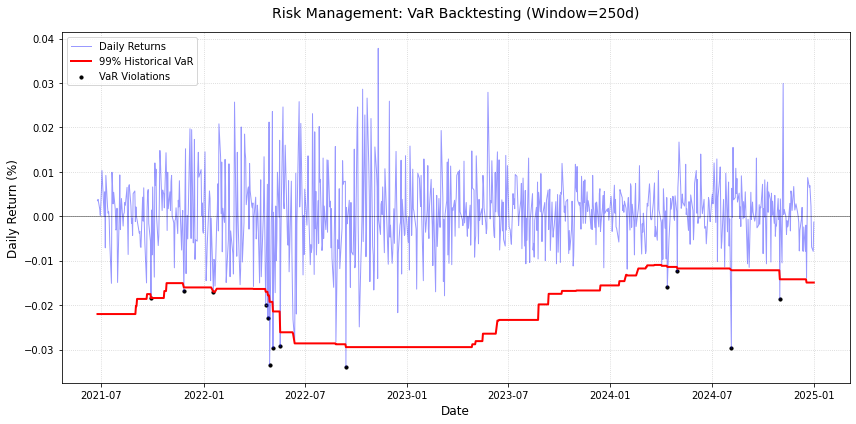

Average VaR: 1.99%
Average CVaR: 2.36%
Days of backtesting: 886days
Count Exception: 13


In [7]:
#---------------------------
#  Evaluate Portfolio
#---------------------------

# Sharpe Ratio
mean_return = np.mean(portfolio_daily_return_CVaR["Portfolio Return"]) * 252
volatility = np.std(portfolio_daily_return_CVaR["Portfolio Return"]) * np.sqrt(252)
sharpe_ratio = mean_return / volatility

print(f"Annualized Return: {mean_return:.2%}")
print(f"Annualized Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Historical 99% VaR, window=250)
window_VaR= 250
cl = 0.99
portfolio_daily_return_CVaR.head()

# Calculate historical VaR
portfolio_daily_return_CVaR['VaR_99_hist'] = portfolio_daily_return_CVaR['Portfolio Return'].rolling(window=window_VaR).quantile(1-cl)

# Calculate historical CVaR
portfolio_daily_return_CVaR['CVaR_99_hist'] = portfolio_daily_return_CVaR['Portfolio Return'].rolling(window=window_VaR).apply(cvar_calculation, raw=False)

# Backtesting
backtest_df = portfolio_daily_return_CVaR.dropna().copy()
backtest_df['Exception'] = backtest_df['Portfolio Return'] < backtest_df['VaR_99_hist']

# Draw Graph
fig, ax = plt.subplots(figsize=(12, 6))

# Daily Return of Portfolio
ax.plot(backtest_df.index, backtest_df['Portfolio Return'],label='Daily Returns', color='blue', alpha=0.4, linewidth=1)
ax.plot(backtest_df.index, backtest_df['VaR_99_hist'],label='99% Historical VaR', color='red', linestyle='-', linewidth=2)

# Highlight the exceptions
exceptions = backtest_df[backtest_df['Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return'], 
           color='black', marker='o', s=10, label='VaR Violations')

ax.set_title(f'Risk Management: VaR Backtesting (Window={window_VaR}d)', fontsize=14, pad=15)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

fig.tight_layout()
plt.show()

# Result
print(f"Average VaR: {abs(np.mean(backtest_df['VaR_99_hist'])):.2%}")
print(f"Average CVaR: {abs(np.mean(backtest_df['CVaR_99_hist'])):.2%}")

print(f"Days of backtesting: {len(backtest_df)}days")
print(f"Count Exception: {backtest_df['Exception'].sum()}")


In [8]:
portfolio_daily_return_CVaR.head()

,Portfolio Return,Cumulative Return,Cumulative Return(%),VaR_99_hist,CVaR_99_hist
Date,,,,,
2020-06-29,0.0090,1.009000,0.900000,NaN,NaN
2020-06-30,0.0146,1.023731,2.373140,NaN,NaN
2020-07-01,0.0120,1.036016,3.601618,NaN,NaN
2020-07-02,0.0058,1.042025,4.202507,NaN,NaN
2020-07-06,0.0232,1.066200,6.620005,NaN,NaN


In [9]:
weights_CVaR_week

,NVDA,AAPL,MSFT,GOOGL,AMZN,META,AVGO,TSLA,BRK-B,JPM,UNH,JNJ,BIL,SHV,GLD
Date,,,,,,,,,,,,,,,
2020-07-03,0.000,0.020,0.02,0.18,0.18,0.017,0.0,0.0,0.15,0.000,0.133,0.15,0.05,0.05,0.05
2020-07-10,0.000,0.020,0.02,0.18,0.18,0.017,0.0,0.0,0.15,0.000,0.133,0.15,0.05,0.05,0.05
2020-07-17,0.000,0.020,0.02,0.18,0.18,0.017,0.0,0.0,0.15,0.000,0.133,0.15,0.05,0.05,0.05
2020-07-24,0.000,0.020,0.02,0.18,0.18,0.017,0.0,0.0,0.15,0.000,0.133,0.15,0.05,0.05,0.05
2020-07-31,0.000,0.020,0.02,0.18,0.18,0.017,0.0,0.0,0.15,0.000,0.133,0.15,0.05,0.05,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-06,0.000,0.097,0.02,0.00,0.00,0.137,0.0,0.0,0.15,0.150,0.146,0.15,0.05,0.05,0.05
2024-12-13,0.000,0.097,0.02,0.00,0.00,0.137,0.0,0.0,0.15,0.150,0.146,0.15,0.05,0.05,0.05
2024-12-20,0.000,0.099,0.02,0.00,0.00,0.131,0.0,0.0,0.15,0.150,0.150,0.15,0.05,0.05,0.05


### Portfolio Weight Dynamics by sectors

In [63]:
def plot_weights(
    weights,
    sector
    ):
    """

    Plot portfolio weight dynamics by asset groups (line plots).
    
    """

    n = len(sector)
    fig, axes = plt.subplots(n, 1, figsize=(14,12))  
    
    for ax, (sectors, assets) in zip(axes, sector.items()):
        weights[assets].plot(ax=ax)
        ax.set_title(sectors)
        ax.set_ylabel("Weight")
        ax.legend(loc="upper right", ncol=3)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Date")
    plt.tight_layout()

    plt.savefig("Portfolio Weight Dynamics.png", dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()

In [11]:
groups = {
    "Growth / Tech": ["NVDA","AAPL","MSFT","GOOGL","AMZN","META"],
    "Financial": ["BRK-B","JPM"],
    "Defensive": ["UNH","JNJ"],
    "Hedge / Cash": ["BIL","SHV","GLD"]
}


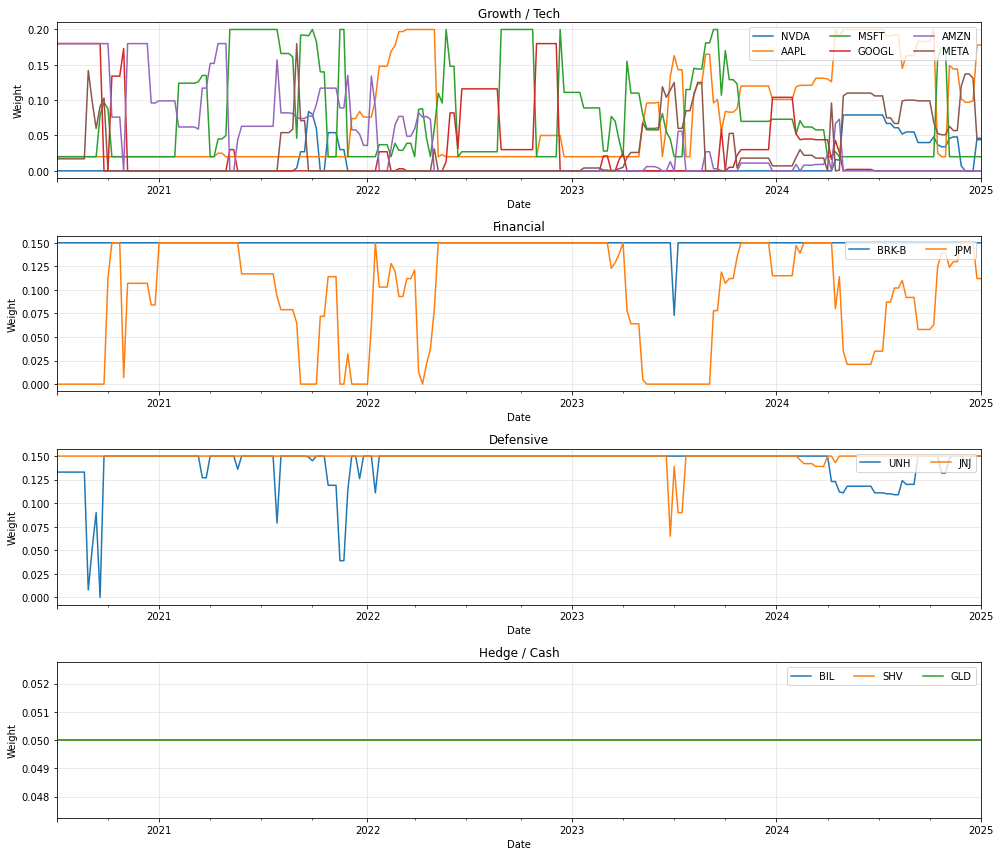

In [64]:
# Weekly rebalancing framework
plot_weights(weights_CVaR_week,groups)


In [13]:
weights_last = weights_CVaR_week.iloc[-1]
weights_last.head()

NVDA     0.046
AAPL     0.178
MSFT     0.020
GOOGL    0.000
AMZN     0.000
Name: 2025-01-03 00:00:00, dtype: float64

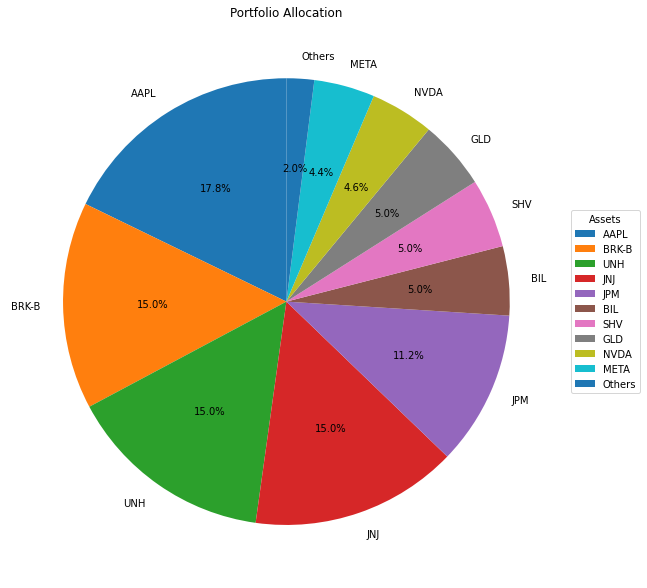

In [65]:
# Lastest Portfolio weights

weights = weights_last.sort_values(ascending=False)

threshold = 0.03
major = weights[weights >= threshold]
minor = weights[weights < threshold]

if len(minor) > 0:
    major["Others"] = minor.sum()

fig, ax = plt.subplots(figsize=(9, 9), facecolor='white')

wedges, texts, autotexts = ax.pie(
    major.values,
    labels=major.index,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title("Portfolio Allocation")
ax.legend(wedges, major.index, title="Assets",
          loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

plt.savefig("CVaR Optimal Asset Allocation.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


### Graph of Daily Return

In [15]:
# Compare with S&P
snp = ["^GSPC"]

snp_data = yf.download(snp, start="2020-06-29", end="2025-01-01", auto_adjust=False)
snp_returns = snp_data.xs('Adj Close', axis=1, level=0).pct_change().dropna()
snp_returns.head()


[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-06-30,0.015410
2020-07-01,0.005022
2020-07-02,0.004541
2020-07-06,0.015882
2020-07-07,-0.010819


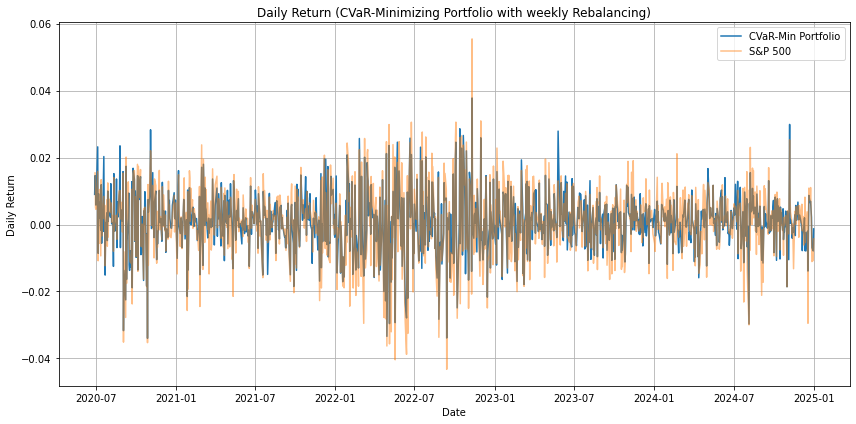

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR["Portfolio Return"], label="CVaR-Min Portfolio")
plt.plot(snp_returns.index, snp_returns, label="S&P 500",alpha=0.5)
plt.title("Daily Return (CVaR-Minimizing Portfolio with weekly Rebalancing)")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("Daily Return of CVaR and SnP.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


### Compounded Return

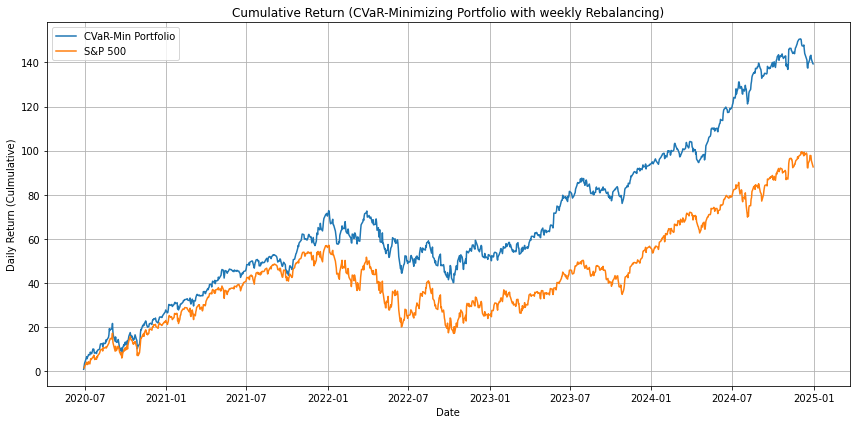

In [62]:
snp_returns_cm = ((1 + snp_returns).cumprod()-1)*100

plt.figure(figsize=(12, 6))
plt.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR["Cumulative Return(%)"], label="CVaR-Min Portfolio")
plt.plot(snp_returns.index, snp_returns_cm, label="S&P 500")
plt.title("Cumulative Return (CVaR-Minimizing Portfolio with weekly Rebalancing)")
plt.xlabel("Date")
plt.ylabel("Daily Return (Culmulative)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("Cumulative Return of CVaR and SnP.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


Our Baseline model is Daily portfolio return rebalanced weekly.

## Calculate ES shares

### Marginal ES
* measures how much the portfolio’s Expected Shortfall would change if the weight of an asset were increased infinitesimally.
* captures the tail riskiness of an asset itself, independent of its current portfolio weight.
* reflects sensitivity

### Component ES
* measures how much of the portfolio’s Expected Shortfall is actually contributed by each asset.
* incorporates both the asset’s tail behavior and its portfolio weight

In [18]:
# ------------------------------------------------------------------------------
# Set up
# ------------------------------------------------------------------------------
daily_block = daily_returns.copy()
daily_block["week"] = daily_block.index.to_period("W-FRI").to_timestamp("W-FRI")
daily_w = daily_block[["week"]].join(weights_CVaR_week, on="week").dropna()

# Return and Weights
R = daily_block.loc[daily_w.index, tickers].values
w = daily_w[tickers].values

# Calculate Losses
loss_asset = -(R * w)          # (T, N)
loss_port  = loss_asset.sum(axis=1)

alpha = 0.95
VaR = np.quantile(loss_port, alpha)
thres = loss_port >= VaR

# ------------------------------------------------------------------------------
# Marginal ES
# Calculated with Finite Difference
# ------------------------------------------------------------------------------

# Calculate CVaR
def cvar_calculation_ES(returns, alpha=0.95):
    loss = -np.asarray(returns)
    var_95 = -np.percentile(returns,(1-alpha)*100)
    tail_loss = loss[loss >= var_95]
    return np.mean(tail_loss)


ES_base = cvar_calculation_ES(-loss_port, alpha=alpha)

# Set up
epsilon = 1e-4
N = len(tickers)
mES = np.zeros(N)

# Slight increase in the weights of each assets
for i in range(N):
    w_shift = w.copy()
    w_shift[:, i] += epsilon

    # This is a "leverage-up" perturbation (sum(w) increases slightly)
    loss_port_shift = (-(R * w_shift)).sum(axis=1)
    ES_pert = cvar_calculation_ES(-loss_port_shift, alpha=alpha)

    mES[i] = (ES_pert - ES_base) / epsilon

# ------------------------------------------------------------------------------
# Component(Compouned) ES
# ------------------------------------------------------------------------------
cES = (-(R * w))[thres].mean(axis=0)

# Proxy can be calculated by mean_weights * mES as well.
mean_weights = w[thres].mean(axis=0)
cES_xy = mean_weights*mES

# ------------------------------------------------------------------------------
# Calculate ES shares for each assets
# ------------------------------------------------------------------------------
ES_total = loss_port[thres].mean()
share = cES / ES_total

# Result
marginal_ES_df = pd.DataFrame({
    "Mean Weight": mean_weights,
    "Marginal ES": mES,
    "Component ES": cES,
    "Component ES (Proxy)": cES_xy,
    "ES Share": share
}, index=tickers).round(6)

print("=== Historical Marginal & Component ES ===")
print(f"CVaR Portfolio Total ES (95%): {ES_total:.6%}\n")
print(marginal_ES_df)



=== Historical Marginal & Component ES ===
CVaR Portfolio Total ES (95%): 1.899868%

       Mean Weight  Marginal ES  Component ES  Component ES (Proxy)  ES Share
NVDA      0.006123     0.043824      0.000282              0.000268  0.014820
AAPL      0.062246     0.029019      0.001785              0.001806  0.093966
MSFT      0.077158     0.030850      0.002463              0.002380  0.129656
GOOGL     0.045404     0.030960      0.001466              0.001406  0.077157
AMZN      0.053456     0.035819      0.001901              0.001915  0.100076
META      0.016018     0.033002      0.000506              0.000529  0.026650
AVGO      0.052246     0.026837      0.001661              0.001402  0.087437
TSLA      0.008246     0.042111      0.000336              0.000347  0.017678
BRK-B     0.150000     0.016045      0.002407              0.002407  0.126678
JPM       0.093825     0.020520      0.002220              0.001925  0.116840
UNH       0.135351     0.016169      0.002237            

## Compare the result with Max-Sharpe Portfolio

Same Framework except for the objective function.

### Weekly Rebalancing Max-Sharpe Strategy (26-Week Lookback, Daily Return)

In [19]:
# Bounds for each stocks
bounds = []
for t in tickers:
    if t in ["AAPL", "MSFT"]:
        bounds.append((0.02, 0.20))   # Core stocks: Min 2%, Max 20%
    elif t in ["NVDA", "TSLA"]:
        bounds.append((0.00, 0.15))   # High vol stocks: Max 15%
    elif t in ["GOOGL", "AMZN", "META", "AVGO"]:
        bounds.append((0.00, 0.18))   # large-cap growth stocks: Max 18%
    elif t in ["BRK-B", "JPM"]:
        bounds.append((0.00, 0.15))   # Finance: Max 15%
    elif t in ["BIL", "SHV","GLD"]:
        bounds.append((0.00, 0.05))   # cash, short-duration Treasuries, and gold
    else:
        bounds.append((0.00, 0.15))

In [20]:
# Weekly Rebalancing & use the weight to construct the week's portfolio return in daily.
# Max-Sharpe Ratio
num_assets = len(tickers)

# Function to compute weights via Sharpe Ratio maximization
def max_sharpe(return_window, rf=0.02):
    mean_returns = return_window.mean() * 252
    cov_matrix = return_window.cov() * 252
    n = len(mean_returns)

    def objective(w):
        ret = np.dot(w, mean_returns)
        vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
        return -(ret - rf) / vol

    init = [1/n] * n
    
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

    result = minimize(objective, init, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# Weekly Compounded Return
weekly_returns = daily_returns.resample('W-FRI').apply(lambda x: (x + 1).prod() - 1)

# Weekly Rebalancing and Backtesting
weights_week = []
portfolio_returns_daily = []

# 26-week lookback window
lookback_window= 26

for i in range(lookback_window, len(weekly_returns)):
    # Daily returns for 26 weeks windows.
    end = weekly_returns.index[i-1] # Last Friday which should be exclude.
    start = end - pd.DateOffset(weeks=lookback_window) # Friday 26 weeks before.
    window_range= (daily_returns.index > start) & (daily_returns.index <= end)

    window = daily_returns.loc[window_range]

    # Optimized weights
    weights = max_sharpe(window)
    weights_week.append(weights)

    # Daily Portfolio Return using weekly Rebalanced portfolio weights
    start_day = weekly_returns.index[i-1]
    end_day = weekly_returns.index[i]
    window_trade= (daily_returns.index > start_day) & (daily_returns.index <= end_day)

    portfolio_day_rebalanced = daily_returns.loc[window_trade].dot(weights)
    portfolio_returns_daily.append(portfolio_day_rebalanced)

# 6. Results
weights_week_sharpe = pd.DataFrame(weights_week, columns=tickers, index=weekly_returns.index[lookback_window:]).round(3)

portfolio_daily_return_sharpe = pd.concat(portfolio_returns_daily).sort_index()
portfolio_daily_return_sharpe.name = "Portfolio Return"

portfolio_daily_return_sharpe = pd.DataFrame(portfolio_daily_return_sharpe)

# Cumulative Return
portfolio_daily_return_sharpe["Cumulative Return"] = (1 + portfolio_daily_return_sharpe["Portfolio Return"]).cumprod()
portfolio_daily_return_sharpe["Cumulative Return(%)"] = ((1 + portfolio_daily_return_sharpe["Portfolio Return"]).cumprod()-1)*100


/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


Annualized Return: 26.33%
Annualized Volatility: 18.98%
Sharpe Ratio: 1.39


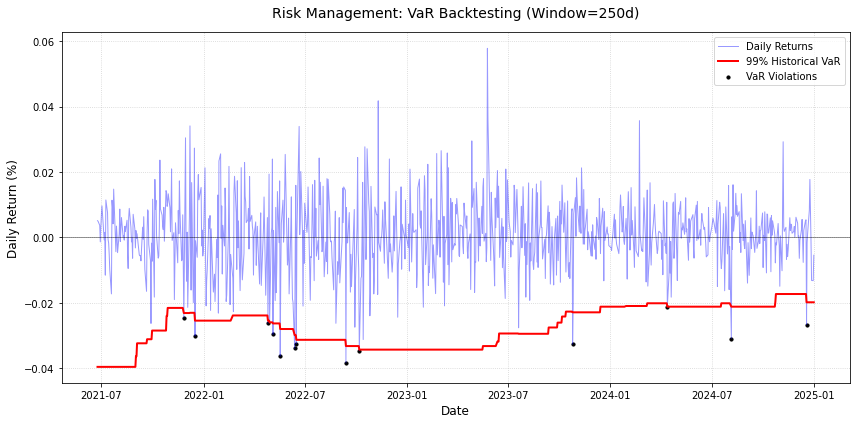

Average VaR: 2.72%
Average CVaR: 3.23%
Days of backtesting: 886days
Count Exception: 13


In [67]:
#---------------------------
#  Evaluate Portfolio
#---------------------------

# Sharpe Ratio
mean_return = np.mean(portfolio_daily_return_sharpe["Portfolio Return"]) * 252
volatility = np.std(portfolio_daily_return_sharpe["Portfolio Return"]) * np.sqrt(252)
sharpe_ratio = mean_return / volatility

print(f"Annualized Return: {mean_return:.2%}")
print(f"Annualized Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Historical 99% VaR, window=250)
window_VaR= 250
cl = 0.99
portfolio_daily_return_sharpe.head()

# Calculate historical VaR
portfolio_daily_return_sharpe['VaR_99_hist'] = portfolio_daily_return_sharpe['Portfolio Return'].rolling(window=window_VaR).quantile(1-cl)

# Calculate historical CVaR
portfolio_daily_return_sharpe['CVaR_99_hist'] = portfolio_daily_return_sharpe['Portfolio Return'].rolling(window=window_VaR).apply(cvar_calculation, raw=False)

# Backtesting
backtest_df = portfolio_daily_return_sharpe.dropna().copy()
backtest_df['Exception'] = backtest_df['Portfolio Return'] < backtest_df['VaR_99_hist']

# Draw Graph
fig, ax = plt.subplots(figsize=(12, 6))

# Daily Return of Portfolio
ax.plot(backtest_df.index, backtest_df['Portfolio Return'],label='Daily Returns', color='blue', alpha=0.4, linewidth=1)
ax.plot(backtest_df.index, backtest_df['VaR_99_hist'],label='99% Historical VaR', color='red', linestyle='-', linewidth=2)

# Highlight the exceptions
exceptions = backtest_df[backtest_df['Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return'], 
           color='black', marker='o', s=10, label='VaR Violations')

ax.set_title(f'Risk Management: VaR Backtesting (Window={window_VaR}d)', fontsize=14, pad=15)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

fig.tight_layout()

plt.savefig("99 percent historical VaR (Max Sharpe).png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Result
print(f"Average VaR: {abs(np.mean(backtest_df['VaR_99_hist'])):.2%}")
print(f"Average CVaR: {abs(np.mean(backtest_df['CVaR_99_hist'])):.2%}")

print(f"Days of backtesting: {len(backtest_df)}days")
print(f"Count Exception: {backtest_df['Exception'].sum()}")


#### CVaR verses Max Sharpe Portfolio

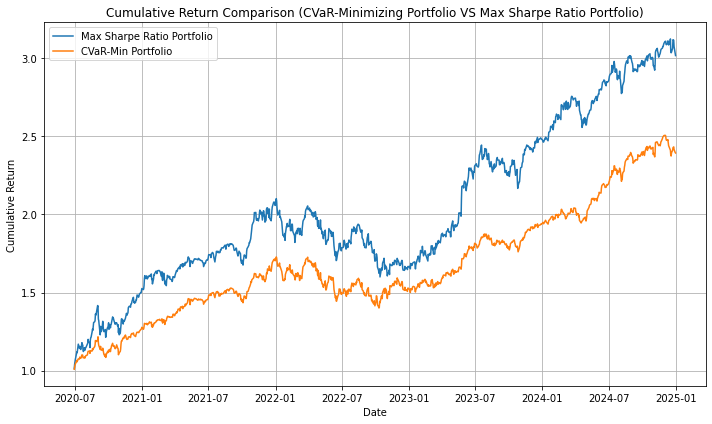

In [76]:
plt.figure(figsize=(10, 6))
plt.plot(portfolio_daily_return_sharpe.index, portfolio_daily_return_sharpe["Cumulative Return"], label="Max Sharpe Ratio Portfolio")
plt.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR["Cumulative Return"], label="CVaR-Min Portfolio")
plt.title("Cumulative Return Comparison (CVaR-Minimizing Portfolio VS Max Sharpe Ratio Portfolio)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("Max Sharpe vs CvaR.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


### Calculate risk with GARCH(1,1)

In [23]:
from arch import arch_model

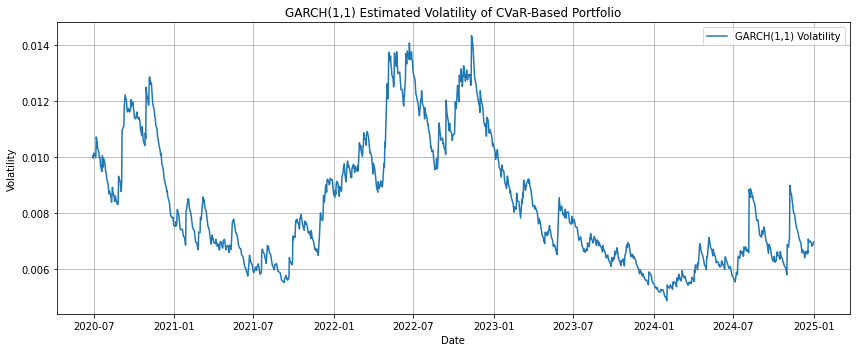

In [24]:
# Calculate Risk with GARCH(1,1)
# GARCH is better in %unit
returns_GARCH = portfolio_daily_return_CVaR["Portfolio Return"] * 100

# Fit GARCH(1,1)
garch_CVaR = arch_model(returns_GARCH,mean='constant', vol='GARCH', p=1, q=1).fit(disp='off')

# Conditional volatility
# Return to decimals
conditional_vol_CVaR = garch_CVaR.conditional_volatility / 100  

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(conditional_vol_CVaR, label='GARCH(1,1) Volatility')
plt.title('GARCH(1,1) Estimated Volatility of CVaR-Based Portfolio')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


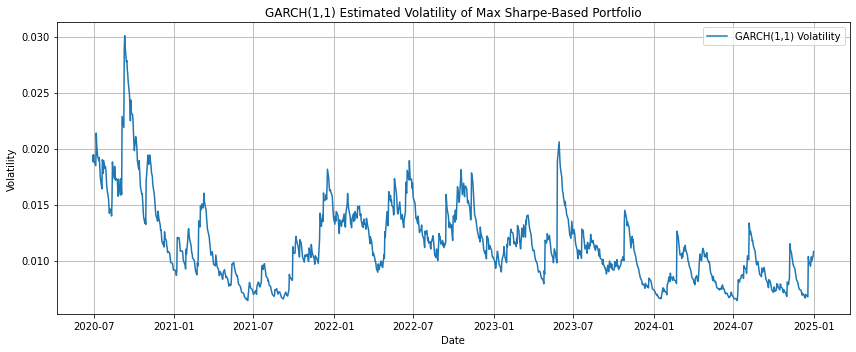

In [25]:
# Calculate Risk with GARCH(1,1)
# GARCH is better in %unit
returns_GARCH = portfolio_daily_return_sharpe["Portfolio Return"] * 100

# Fit GARCH(1,1)
garch_CVaR = arch_model(returns_GARCH,mean='constant', vol='GARCH', p=1, q=1).fit(disp='off')

# Conditional volatility
# Return to decimals
conditional_vol_sharpe = garch_CVaR.conditional_volatility / 100  

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(conditional_vol_sharpe, label='GARCH(1,1) Volatility')
plt.title('GARCH(1,1) Estimated Volatility of Max Sharpe-Based Portfolio')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


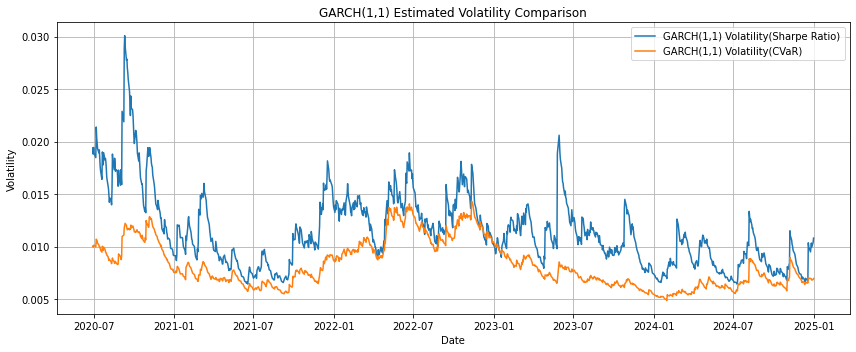

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(conditional_vol_sharpe, label='GARCH(1,1) Volatility(Sharpe Ratio)')
plt.plot(conditional_vol_CVaR, label='GARCH(1,1) Volatility(CVaR)')
plt.title('GARCH(1,1) Estimated Volatility Comparison')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("GARCH.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


In [27]:
# Compare Average and Max level of volatility
print("<Compare Average and Max level of volatility>")
print("="*45)
print(f"Avg Volatility of CVaR portfolio: {conditional_vol_CVaR.mean():.2%}")
print(f"Avg Volatility of Sharpe portfolio: {conditional_vol_sharpe.mean():.2%}")
print("="*45)
print(f"Avg Volatility of CVaR portfolio: {conditional_vol_CVaR.max():.2%}")
print(f"Avg Volatility of Sharpe portfolio: {conditional_vol_sharpe.max():.2%}")

<Compare Average and Max level of volatility>
Avg Volatility of CVaR portfolio: 0.83%
Avg Volatility of Sharpe portfolio: 1.15%
Avg Volatility of CVaR portfolio: 1.43%
Avg Volatility of Sharpe portfolio: 3.01%


### Appendix: Using GARCH, GJR-GARCH, SVR-GARCH, build volatility forecasting model 
* Evaluate with MSE.

In [28]:
from sklearn.metrics import mean_squared_error as mse

In [29]:
split_date= portfolio_daily_return_CVaR["Portfolio Return"].iloc[-126:].index

# Hull evaluate volatility forecasts by using a 5-day rolling standard deviation of daily returns as proxy for realized volatility.
real_vol= portfolio_daily_return_CVaR["Portfolio Return"].rolling(5).std()
real_vol_test=real_vol[split_date]

# Forecast
# Forecasting using GARCH(1,1)

forecast= garch_CVaR.forecast(start=split_date[0])
forecast_vol= np.sqrt(forecast.variance.iloc[:,0])/100

In [30]:
# RMSE to evaluate the forecast.

def RMSE(real_vol,forecast_vol):
    fv,rv = forecast_vol.align(real_vol,join='inner')
    rmse = np.sqrt(mse(fv,rv))
    return rmse

In [31]:
rmse_garch=RMSE(real_vol_test,forecast_vol)
print('The RMSE value of GARCH Model is {:.4f}'.format(rmse_garch))

The RMSE value of GARCH Model is 0.0040


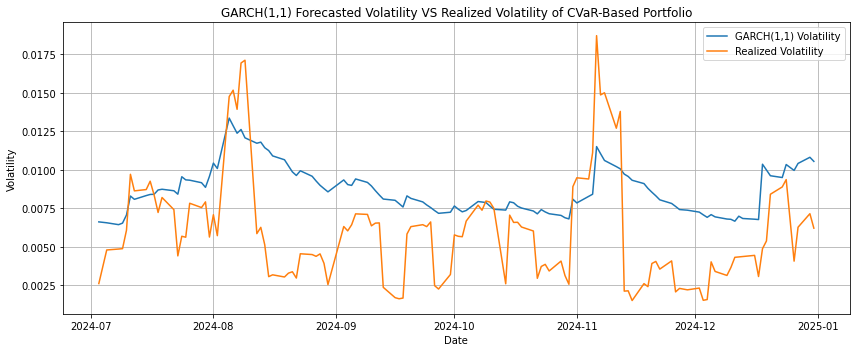

In [73]:
# Forecast VS Realized

plt.figure(figsize=(12, 5))
plt.plot(forecast_vol, label='GARCH(1,1) Volatility')
plt.plot(real_vol_test, label='Realized Volatility')
plt.title('GARCH(1,1) Forecasted Volatility VS Realized Volatility of CVaR-Based Portfolio')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("Forecasting_GARCH.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

In [33]:
# Use GJR-GARCH

bic_gjr = []

for p in range(1,5):
    for q in range(1,5):
        gjrgarch = arch_model(portfolio_daily_return_CVaR["Portfolio Return"], 
                                mean='zero', p=p,o=1,q=q).fit(disp='off')
        bic_gjr.append(gjrgarch.bic)
        if gjrgarch.bic == np.min(bic_gjr):
            best_param = p,q

p,q

/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.378e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.378e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/choejunhoe/opt/anaconda3/lib/python

(4, 4)

In [34]:
gjr_garch = arch_model(portfolio_daily_return_CVaR["Portfolio Return"]*100,
                                mean='constant', p=p,o=1,q=q).fit(disp='off')

forecast_gjr= gjr_garch.forecast(start=split_date[0])
forecast_gjr_vol= np.sqrt(forecast_gjr.variance.iloc[:,0])/100

rmse_gjr = RMSE(real_vol_test,forecast_gjr_vol)

print(f'The RMSE value of GJR-GARCH Model is {rmse_gjr:.7f}')
print(f'The RMSE value of GARCH Model is {rmse_garch:.7f}')

if rmse_gjr < rmse_garch: 
    print("GJR-GARCH is better.")
elif rmse_gjr == rmse_garch:
    print("Both MSE are the same.")
else: 
    print("GARCH is better.")


The RMSE value of GJR-GARCH Model is 0.0033979
The RMSE value of GARCH Model is 0.0039963
GJR-GARCH is better.


In [35]:
print(gjr_garch.summary())


                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:       Portfolio Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -1353.85
Distribution:                  Normal   AIC:                           2729.69
Method:            Maximum Likelihood   BIC:                           2785.07
                                        No. Observations:                 1135
Date:                Thu, Apr 30 2026   Df Residuals:                     1134
Time:                        14:53:50   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0772  4.211e-02      1.833  6.685e-02 [-5.36

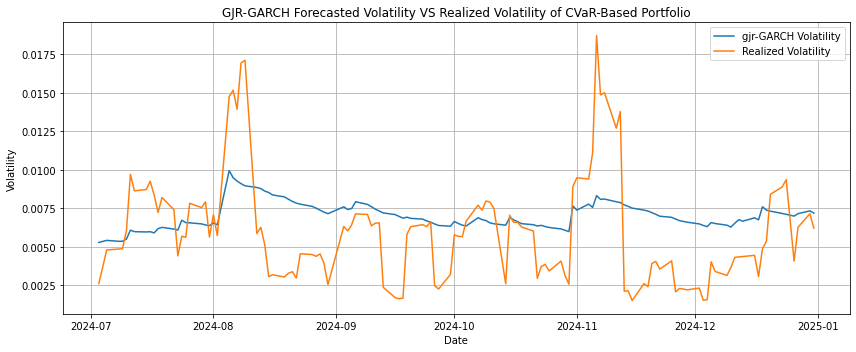

In [74]:
# Forecast VS Realized

plt.figure(figsize=(12, 5))
plt.plot(forecast_gjr_vol, label='gjr-GARCH Volatility')
plt.plot(real_vol_test, label='Realized Volatility')
plt.title('GJR-GARCH Forecasted Volatility VS Realized Volatility of CVaR-Based Portfolio')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("Forecasting_GJR_GARCH.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

SVR-GARCH Model

Three kind.
* linear
* Polynomial
* Radial Basis Function

In [37]:
import numpy as np, pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from arch import arch_model

In [38]:
return_CVaR = portfolio_daily_return_CVaR["Portfolio Return"].dropna()


# Generate Features

X_CVaR = pd.concat({
                'r_lag1': return_CVaR.shift(1),
                'r_lag2': return_CVaR.shift(2),
                'r_lag5': return_CVaR.shift(5),
                'r_ma5' : return_CVaR.shift(1).rolling(5).mean(),
                'r_ma10': return_CVaR.shift(1).rolling(10).mean(),
}, axis=1).dropna()

# Target: Portfolio Return
y = return_CVaR.loc[X_CVaR.index]

# Split Data (90:10)
split = int(len(X_CVaR)*0.80)
X_train, X_test = X_CVaR.iloc[:split], X_CVaR.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Estimate Conditional Mean with SVR
svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', 
            SVR(kernel='linear',  # Radial Basis Function
            C=5.0,             # Regularization
            epsilon=0.001,     # Epsilon insentive margin width
            gamma='scale'))
])

svr.fit(X_train, y_train)

# Residuals
yhat_train = pd.Series(svr.predict(X_train), index=X_train.index)
yhat_test = pd.Series(svr.predict(X_test), index=X_test.index)

residual_train = y_train - yhat_train
residual_test = y_test - yhat_test

# Fit GARCH(1,1) on train residual
model_SVR_GARCH = arch_model(residual_test*100,mean='zero',vol='GARCH',p=1,o=1,q=1,dist='t').fit(disp='off')

# Forecast volatility using above fit model
forecast = model_SVR_GARCH.forecast(start=residual_test.index[0])
forecast_vol_SVR = np.sqrt(forecast.variance.iloc[:,0])/100


In [39]:
# Calculate RMSE

real_vol_SVR = return_CVaR.rolling(5).std().loc[forecast_vol_SVR.index]
rmse_svr = RMSE(real_vol_SVR,forecast_vol_SVR)
print(f"The RMSE value of GARCH Model is {rmse_garch:.7f}")
print(f"The RMSE value of GJR-GARCH Model is {rmse_gjr:.7f}")
print(f"The RMSE value of SVR-GARCH Model is {rmse_svr:.7f}")

if rmse_gjr < rmse_svr: 
    print("GJR-GARCH is better.")
elif rmse_gjr == rmse_garch:
    print("Both MSE are the same.")
else: 
    print("SVR-GARCH is better.")


The RMSE value of GARCH Model is 0.0039963
The RMSE value of GJR-GARCH Model is 0.0033979
The RMSE value of SVR-GARCH Model is 0.0027814
SVR-GARCH is better.


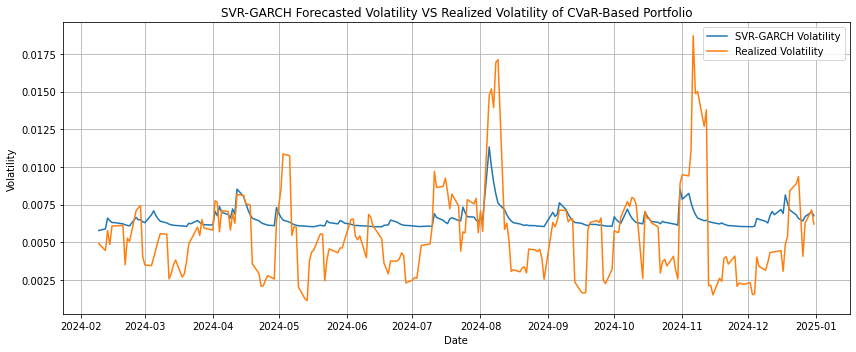

In [75]:
# Forecast VS Realized

plt.figure(figsize=(12, 5))
plt.plot(forecast_vol_SVR, label='SVR-GARCH Volatility')
plt.plot(real_vol_SVR, label='Realized Volatility')
plt.title('SVR-GARCH Forecasted Volatility VS Realized Volatility of CVaR-Based Portfolio')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("Forecasting_SVR_GARCH.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

In [41]:
# Calculate Historical CVaR
def cvar_calculation(returns, cl=0.99):
        var = returns.quantile(1-cl)
        ES= returns[returns <= var].mean()
        return ES

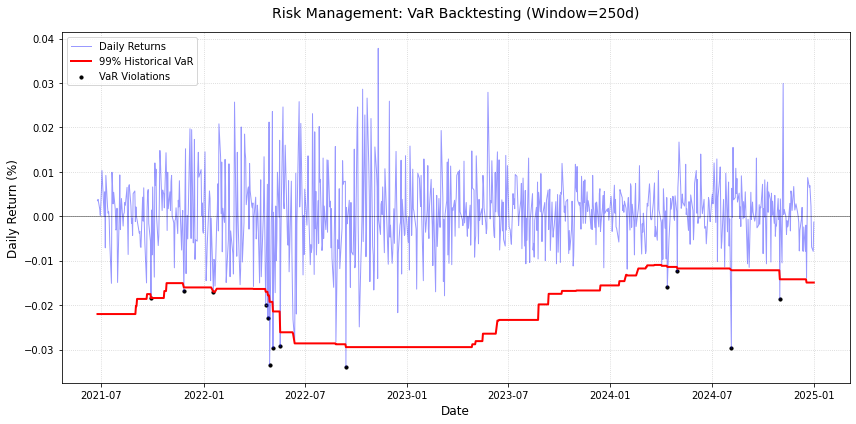

Days of backtesting: 886days
Count Exception: 13
Average VaR: 1.99%
Average CVaR: 2.36%


In [68]:
# Historical VaR 계산 (99% 신뢰수준, window=250)
window_VaR= 250
cl = 0.99
portfolio_daily_return_CVaR.head()

# Calculate historical VaR
portfolio_daily_return_CVaR['VaR_99_hist'] = portfolio_daily_return_CVaR['Portfolio Return'].rolling(window=window_VaR).quantile(1-cl)

# Calculate historical CVaR
portfolio_daily_return_CVaR['CVaR_99_hist'] = portfolio_daily_return_CVaR['Portfolio Return'].rolling(window=window_VaR).apply(cvar_calculation, raw=False)

# Backtesting
backtest_df = portfolio_daily_return_CVaR.dropna().copy()
backtest_df['Exception'] = backtest_df['Portfolio Return'] < backtest_df['VaR_99_hist']

# Draw Graph
fig, ax = plt.subplots(figsize=(12, 6))

# Daily Return of Portfolio
ax.plot(backtest_df.index, backtest_df['Portfolio Return'],label='Daily Returns', color='blue', alpha=0.4, linewidth=1)
ax.plot(backtest_df.index, backtest_df['VaR_99_hist'],label='99% Historical VaR', color='red', linestyle='-', linewidth=2)

# Highlight the exceptions
exceptions = backtest_df[backtest_df['Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return'], 
           color='black', marker='o', s=10, label='VaR Violations')

ax.set_title(f'Risk Management: VaR Backtesting (Window={window_VaR}d)', fontsize=14, pad=15)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

fig.tight_layout()

plt.savefig("99 percent historical VaR (CVaR Opt).png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Result
print(f"Days of backtesting: {len(backtest_df)}days")
print(f"Count Exception: {backtest_df['Exception'].sum()}")
print(f"Average VaR: {abs(np.mean(backtest_df['VaR_99_hist'])):.2%}")
print(f"Average CVaR: {abs(np.mean(backtest_df['CVaR_99_hist'])):.2%}")

### Recall GARCH Models. I will now apply GARCH model to VaR_99.

**Why?**

* GARCH Model captures Volatility Clustering. When Market Volatility increases, sometimes above historical VaR could not adjust the fluctuation.

In [43]:
from scipy.stats import norm
import scipy.integrate as integrate
from scipy.stats import chi2

In [44]:
def kupiec_pof_test(exc, total_obs, cl=0.99):
    """
    Kupiec POF (Proportion of Failures) Test
    H0: The model's failure rate is equal to the expected failure rate (1-CL).
    """
    p_expected = 1 - cl
    p_observed = exc / total_obs

    # Likelihood Ratio
    # LR = -2 * ln( (p^x * (1-p)^(N-x)) / (hat_p^x * (1-hat_p)^(N-x)) )
    numerator = (p_expected ** exc) * ((1 - p_expected) ** (total_obs - exc))
    denominator = (p_observed ** exc) * ((1 - p_observed) ** (total_obs - exc))
    
    lr_stat = -2 * np.log(numerator / denominator)
    
    # P-value from Chi-square distribution (df=1)
    p_value = 1 - chi2.cdf(lr_stat, 1)
    
    result = "Pass" if p_value > 0.05 else "Fail"
    
    print(f"=== Kupiec POF Test Results ===")
    print(f"Expected Failures : {total_obs * p_expected:.2f}")
    print(f"Actual Failures   : {exc}")
    print(f"LR Statistic      : {lr_stat:.4f}")
    print(f"P-value           : {p_value:.4f}")
    print(f"Result            : {result} (at {cl*100}% confidence)")
    
    return result

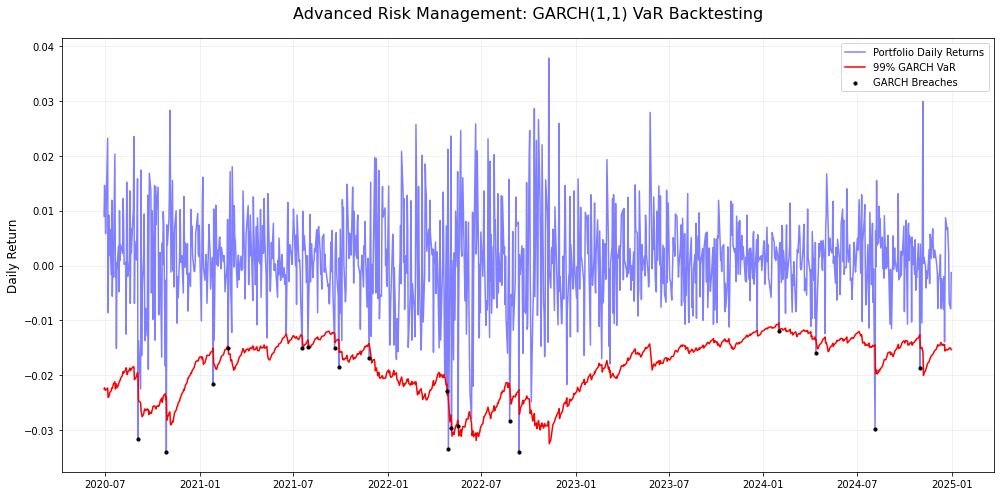

Days of backtesting: 1135days
Count Exception: 19
Average VaR: 1.84%

=== Kupiec POF Test Results ===
Expected Failures : 11.35
Actual Failures   : 19
LR Statistic      : 4.3306
P-value           : 0.0374
Result            : Fail (at 99.0% confidence)


'Fail'

In [69]:
# Recall the code above.
cl=0.99

# Calculate Risk with GARCH(1,1) with normal distribution
# GARCH is better in %unit
returns_GARCH = portfolio_daily_return_CVaR["Portfolio Return"] * 100

# Fit GARCH(1,1)
res_garch_CVaR = arch_model(returns_GARCH,mean='constant', vol='GARCH', p=1, q=1).fit(disp='off')

# Calculate VaR 99%
# Use below 1% of the normal distribution
z_stat = norm.ppf(1-cl)

# Conditional volatility & mean
# Return to decimals
conditional_vol_CVaR = res_garch_CVaR.conditional_volatility / 100  
mu_garch = res_garch_CVaR.params['mu'] / 100

# Parametric VaR 99%
portfolio_daily_return_CVaR['VaR_99_GARCH'] = mu_garch + (z_stat * conditional_vol_CVaR)

# Find exceptions
portfolio_daily_return_CVaR['GARCH_Exception'] = portfolio_daily_return_CVaR['Portfolio Return'] < portfolio_daily_return_CVaR['VaR_99_GARCH']

# Graph
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR['Portfolio Return'], 
        label='Portfolio Daily Returns', color='blue', alpha=0.5, zorder=1)

# GARCH VaR Line
ax.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR['VaR_99_GARCH'], 
        label='99% GARCH VaR', color='red', lw=1.5, zorder=2)

# Exception points
exceptions = portfolio_daily_return_CVaR[portfolio_daily_return_CVaR['GARCH_Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return'], 
           color='black', marker='o', s=10, label='GARCH Breaches', zorder=3)

ax.set_title(f'Advanced Risk Management: GARCH(1,1) VaR Backtesting', fontsize=16, pad=20)
ax.set_ylabel('Daily Return', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()

plt.savefig("99 percent GARCH(1,1)-VaR.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Result
obs= len(portfolio_daily_return_CVaR)
n_except = portfolio_daily_return_CVaR['GARCH_Exception'].sum()
VaR_mean= abs(np.mean(portfolio_daily_return_CVaR['VaR_99_GARCH']))


print(f"Days of backtesting: {obs}days")
print(f"Count Exception: {n_except}")
print(f"Average VaR: {VaR_mean:.2%}")

print(""*20)
print("=="*20)
print("=="*20)

# Kupiec Test for exceptions
kupiec_pof_test(n_except, obs, 0.99)


In [46]:
# Calculate parametric CVaR
# I will use two methods for robustness check.
alpha = 1-cl

In [47]:
# 1. Using pdf formula

# Calculate parametric CVaR
pdf = norm.pdf(z_stat)
alpha = 1-cl
# CVaR: mu - sigma * (pdf(z) / alpha)
# Expected Shortfall factor for Standard Normal Distribution = -pdf(z) / alpha
es_factor = -pdf / alpha
portfolio_daily_return_CVaR['CVaR_99_GARCH_es_factor'] = mu_garch + (conditional_vol_CVaR * es_factor)

print(f"Average CVaR: {abs(np.mean(portfolio_daily_return_CVaR[['CVaR_99_GARCH_es_factor']])):.2%}")

Average CVaR: 2.12%


In [48]:
# 2. Use integral 

# Define the Integrand
def integrand(x):
    return x * norm.pdf(x)

# Integral: -infinite to VaR Critical Value(z_stat)
result_integral = integrate.quad(integrand, -np.inf, z_stat)[0]
es_integral = result_integral / (alpha)

# Rescaling
# CVaR_t = mu_t + sigma_t * (Standard_ES_by_Integration)
portfolio_daily_return_CVaR['CVaR_99_GARCH_Integral'] = mu_garch + (conditional_vol_CVaR * es_integral)

print(f"Average CVaR: {abs(np.mean(portfolio_daily_return_CVaR[['CVaR_99_GARCH_Integral']])):.2%}")

Average CVaR: 2.12%


In [49]:
# Kupiec Test failed with Normal distribution.
# Use t-distribution

# Calculate Risk with GARCH(1,1)
# GARCH is better in %unit
returns_GARCH = portfolio_daily_return_CVaR["Portfolio Return"] * 100

# Fit GARCH(1,1) with t-distribution
res_garch_CVaR = arch_model(returns_GARCH,mean='constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')

# Calculate CaR 99%
# Use below 1% of the t-distribution
df_t = res_garch_CVaR.params['nu'] # Degree of Freedom
t_stat = res_garch_CVaR.model.distribution.ppf(0.01, df_t)

# Conditional volatility & mean
# Return to decimals
conditional_vol_CVaR = res_garch_CVaR.conditional_volatility / 100  
mu_garch = res_garch_CVaR.params['mu'] / 100

# VaR 99%
portfolio_daily_return_CVaR['VaR_99_GARCH'] = mu_garch + (t_stat * conditional_vol_CVaR)

# Find exceptions
portfolio_daily_return_CVaR['GARCH_Exception'] = portfolio_daily_return_CVaR['Portfolio Return'] < portfolio_daily_return_CVaR['VaR_99_GARCH']

# Result
n_except = portfolio_daily_return_CVaR['GARCH_Exception'].sum()

print(f"Days of backtesting: {len(portfolio_daily_return_CVaR)}days")
print(f"Count Exception: {n_except}")
print(f"Average VaR: {abs(np.mean(portfolio_daily_return_CVaR['VaR_99_GARCH'])):.2%}")

print(""*20)
print("=="*20)
print("=="*20)

# Kupiec Test for exceptions
kupiec_pof_test(n_except, 
                len(portfolio_daily_return_CVaR), 
                0.99)



Days of backtesting: 1135days
Count Exception: 15
Average VaR: 2.01%

=== Kupiec POF Test Results ===
Expected Failures : 11.35
Actual Failures   : 15
LR Statistic      : 1.0768
P-value           : 0.2994
Result            : Pass (at 99.0% confidence)


'Pass'

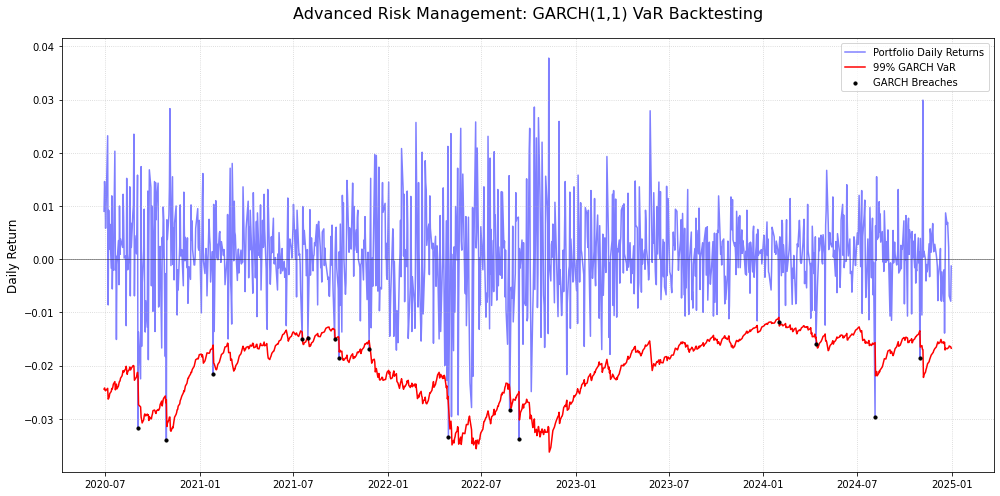

In [50]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR['Portfolio Return'], 
        label='Portfolio Daily Returns', color='blue', alpha=0.5, zorder=1)

# GARCH VaR Line
ax.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR['VaR_99_GARCH'], 
        label='99% GARCH VaR', color='red', lw=1.5, zorder=2)

# Exception points
exceptions = portfolio_daily_return_CVaR[portfolio_daily_return_CVaR['GARCH_Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return'], 
           color='black', marker='o', s=10, label='GARCH Breaches', zorder=3)

ax.set_title(f'Advanced Risk Management: GARCH(1,1) VaR Backtesting', fontsize=16, pad=20)
ax.set_ylabel('Daily Return', fontsize=12)
ax.legend(loc='upper right')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

In [51]:
# Use GJR-GARCH

bic_gjr = []

for p in range(1,5):
    for q in range(1,5):
        gjrgarch = arch_model(portfolio_daily_return_CVaR["Portfolio Return"], 
                                mean='zero', p=p,o=1,q=q).fit(disp='off')
        bic_gjr.append(gjrgarch.bic)
        if gjrgarch.bic == np.min(bic_gjr):
            best_param = p,q

p,q

/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.378e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/choejunhoe/opt/anaconda3/lib/python3.9/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.378e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/choejunhoe/opt/anaconda3/lib/python

(4, 4)

In [52]:
gjr_garch = arch_model(portfolio_daily_return_CVaR["Portfolio Return"]*100,
                                mean='constant', p=p,o=1,q=q).fit(disp='off')

mu_gjr = gjr_garch.params['mu'] / 100
sigma_gjr = gjr_garch.conditional_volatility / 100

# Normal distribution to calculate VaR 99%
z_stat = norm.ppf(0.01) 

# Calulate Parametric VaR
portfolio_daily_return_CVaR['VaR_99_Norm_gjr'] = mu_gjr + (z_stat * sigma_gjr)

# Backtesting: Count Exceptions
portfolio_daily_return_CVaR['gjr_Exception'] = portfolio_daily_return_CVaR['Portfolio Return'] < portfolio_daily_return_CVaR['VaR_99_Norm_gjr']

# Result
n_exc_norm = portfolio_daily_return_CVaR['gjr_Exception'].sum()

print(f"Days of backtesting: {len(portfolio_daily_return_CVaR)}days")
print(f"Count Exception: {n_exc_norm}")
print(f"Average VaR: {abs(np.mean(portfolio_daily_return_CVaR['VaR_99_Norm_gjr'])):.2%}")

print(""*20)
print("=="*20)
print("=="*20)

# Kupiec Test for exceptions
kupiec_pof_test(n_exc_norm, 
                len(portfolio_daily_return_CVaR), 
                0.99)

Days of backtesting: 1135days
Count Exception: 17
Average VaR: 1.84%

=== Kupiec POF Test Results ===
Expected Failures : 11.35
Actual Failures   : 17
LR Statistic      : 2.4643
P-value           : 0.1165
Result            : Pass (at 99.0% confidence)


'Pass'

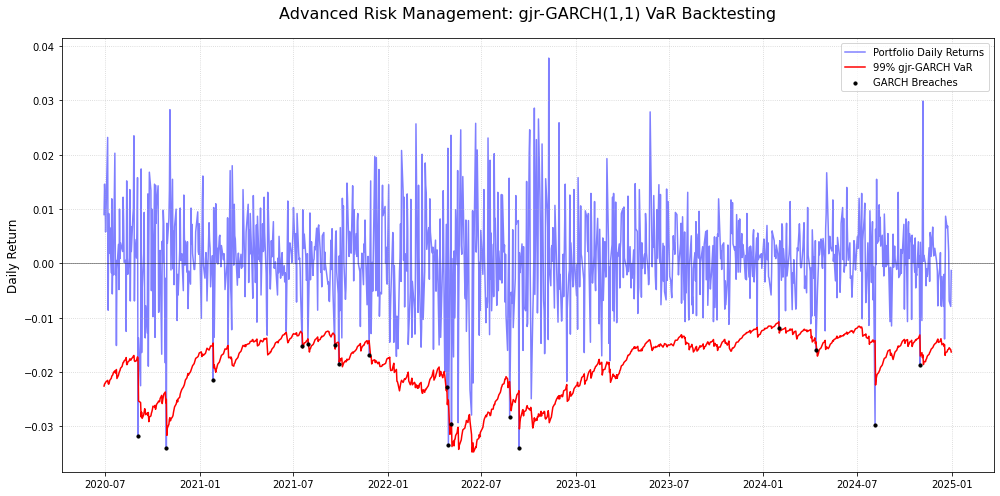

In [70]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR['Portfolio Return'], 
        label='Portfolio Daily Returns', color='blue', alpha=0.5, zorder=1)

# GARCH VaR Line
ax.plot(portfolio_daily_return_CVaR.index, portfolio_daily_return_CVaR['VaR_99_Norm_gjr'], 
        label='99% gjr-GARCH VaR', color='red', lw=1.5, zorder=2)

# Exception points
exceptions = portfolio_daily_return_CVaR[portfolio_daily_return_CVaR['gjr_Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return'], 
           color='black', marker='o', s=10, label='GARCH Breaches', zorder=3)

ax.set_title(f'Advanced Risk Management: gjr-GARCH(1,1) VaR Backtesting', fontsize=16, pad=20)
ax.set_ylabel('Daily Return', fontsize=12)
ax.legend(loc='upper right')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

plt.tight_layout()

plt.savefig("99 percent gjr-GARCH VaR.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

### SVR-GARCH

In [54]:
from scipy.stats import t

In [55]:
return_CVaR = portfolio_daily_return_CVaR["Portfolio Return"].dropna()
cl=0.99
alpha=1-cl

# Generate Features

X_CVaR = pd.concat({
                'r_lag1': return_CVaR.shift(1),
                'r_lag2': return_CVaR.shift(2),
                'r_lag5': return_CVaR.shift(5),
                'r_ma5' : return_CVaR.shift(1).rolling(5).mean(),
                'r_ma10': return_CVaR.shift(1).rolling(10).mean(),
}, axis=1).dropna()

# Target: Portfolio Return
y = return_CVaR.loc[X_CVaR.index]

# Estimate Conditional Mean with SVR
svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', 
            SVR(kernel='linear',  # Radial Basis Function
            C=5.0,             # Regularization
            epsilon=0.001,     # Epsilon insentive margin width
            gamma='scale'))
])

svr.fit(X_CVaR, y)

# Residuals
yhat = pd.Series(svr.predict(X_CVaR), index=X_CVaR.index)
residual = y - yhat

# Fit GARCH(1,1) on residual
model_SVR_GARCH = arch_model(residual*100,mean='zero',vol='GARCH',p=1,o=1,q=1,dist='t').fit(disp='off')

# Calculate VaR 99%
df_t = model_SVR_GARCH.params['nu']
t_stat = model_SVR_GARCH.model.distribution.ppf(alpha, df_t)
sigma_SVR = model_SVR_GARCH.conditional_volatility / 100

# Calculate VaR 99%
# Instead of mean, use estimation result from SVR
portfolio_daily_return_CVaR.loc[X_CVaR.index,'VaR_99_SVR'] = yhat + (t_stat * sigma_SVR)

# Calculate CVaR 99%

# ---------------------------------------------------------------------------------------------------------------
# CVaR Calculation using Integration (With Scaling Correction)
# [Why Scaling?]
# Rescale due to using "scipy"
# You calculated the quantile (threshold) using arch (t_stat), which assumes a variance of 1. 
# However, you are feeding this number into scipy for integration, which assumes a variance greater than 1.
# ----------------------------------------------------------------------------------------------------------------
std_scale = np.sqrt((df_t - 2) / df_t)

# Rescale fo Scipy integral (Standardized -> Unstandardized)
t_stat_classic = t_stat / std_scale

# Integrand
def integrand_t(x,df):
    return x * t.pdf(x, df=df)

integral_result = integrate.quad(integrand_t, -np.inf, t_stat_classic, 
                                    args=(df_t,))[0] # Degree of Freedom

es_classic_t = integral_result / alpha

# Rescale to Arch world (Standardized)
# GARCH's sigma_t is assuming 'variance=1'. Hence, coef should be also rescaled.
es_standard_t = es_classic_t * std_scale

# Rescaling CVaR
portfolio_daily_return_CVaR.loc[X_CVaR.index, 'CVaR_99_SVR'] = yhat + (sigma_SVR * es_classic_t)

# Find Exceptions
# Drop the NA since first dates which are used for MA(10) will be empty
backtest_svr = portfolio_daily_return_CVaR.dropna(subset=['VaR_99_SVR']).copy()
backtest_svr['SVR_CVaR'] = portfolio_daily_return_CVaR.loc[backtest_svr.index,['CVaR_99_SVR']]

backtest_svr['SVR_Exception'] = backtest_svr['Portfolio Return'] < backtest_svr['VaR_99_SVR']

# Result
n_exc_SVR = backtest_svr['SVR_Exception'].sum()
print(f"Days of backtesting: {len(portfolio_daily_return_CVaR)}days")
print(f"Count Exception: {n_exc_SVR}")
print(f"Average VaR: {abs(np.mean(backtest_svr['VaR_99_SVR'])):.2%}")
print(f"Average CVaR: {abs(np.mean(backtest_svr['CVaR_99_SVR'])):.2%}")

print(""*20)
print("=="*20)
print("=="*20)

# Kupiec Test for exceptions
kupiec_pof_test(n_exc_SVR, 
                len(portfolio_daily_return_CVaR), 
                0.99)


Days of backtesting: 1135days
Count Exception: 13
Average VaR: 2.01%
Average CVaR: 3.03%

=== Kupiec POF Test Results ===
Expected Failures : 11.35
Actual Failures   : 13
LR Statistic      : 0.2314
P-value           : 0.6305
Result            : Pass (at 99.0% confidence)


'Pass'

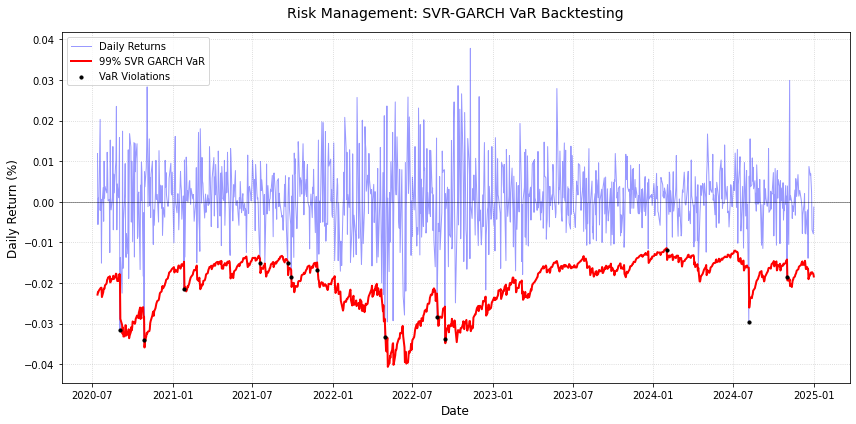

Days of backtesting: 1125days
Count Exception: 13
=== Kupiec POF Test Results ===
Expected Failures : 11.25
Actual Failures   : 13
LR Statistic      : 0.2619
P-value           : 0.6088
Result            : Pass (at 99.0% confidence)


'Pass'

In [71]:
# Draw Graph
fig, ax = plt.subplots(figsize=(12, 6))

# Daily Return of Portfolio
ax.plot(backtest_svr.index, backtest_svr['Portfolio Return'],label='Daily Returns', color='blue', alpha=0.4, linewidth=1)
ax.plot(backtest_svr.index, backtest_svr['VaR_99_SVR'],label='99% SVR GARCH VaR', color='red', linestyle='-', linewidth=2)

# Highlight the exceptions
exceptions_svr = backtest_svr[backtest_svr['SVR_Exception']]

ax.scatter(exceptions_svr.index, exceptions_svr['Portfolio Return'], color='black', marker='o', s=10, label='VaR Violations',zorder=5)

ax.set_title(f'Risk Management: SVR-GARCH VaR Backtesting', fontsize=14, pad=15)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

fig.tight_layout()

plt.savefig("99 percent SVR-GARCH VaR.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Result
print(f"Days of backtesting: {len(backtest_svr)}days")
print(f"Count Exception: {backtest_svr['SVR_Exception'].sum()}")

kupiec_pof_test(backtest_svr['SVR_Exception'].sum(),
                len(backtest_svr), 
                0.99)

## Monthly Rebalancing CVaR Backtest (6-Month Rolling Window)

### Framework
* This section implements a monthly rebalanced portfolio strategy. 
* At each month $t$, portfolio weights are re-optimized by minimizing CVaR using the most recent 12 months of return data. 
* The resulting weights are applied to the next month’s realized returns to generate the strategy’s backtested performance.

In [57]:
#------------------------------------------------------
# Monthly Rebalancing
#------------------------------------------------------

# This will be used for Pie Chart

# Monthly Compounded Return
monthly_returns = daily_returns.resample('MS').apply(lambda x: (x + 1).prod() - 1)

# Monthly Rebalancing and Backtesting
weights_m = []
portfolio_returns_m = []

# Monthly lookback window
lookback_m= 6

for i in range(lookback_m, len(monthly_returns)):
    # Daily returns for 6 month windows.
    start = monthly_returns.index[i-lookback_m]   
    end   = monthly_returns.index[i] - pd.Timedelta(days=1) # Data is in 'MS'
    window = daily_returns.loc[start:end]

    # Optimized weights
    weights,_ ,_ = minimize_cvar(window, bounds)
    weights_m.append(weights)

    # Daily Portfolio Return using monthly Rebalanced portfolio weights
    start_day = monthly_returns.index[i]
    end_day = start_day + pd.DateOffset(months=1)

    window_trade= (daily_returns.index >= start_day) & (daily_returns.index < end_day)

    portfolio_day_rebalanced = daily_returns.loc[window_trade].dot(weights)
    portfolio_returns_m.append(portfolio_day_rebalanced)

# Rebalancing Results
weighs_CVaR_m = pd.DataFrame(   weights_m, 
                                columns=tickers, 
                                index=monthly_returns.index[lookback_m:]).round(3)

portfolio_returns_m = pd.concat(portfolio_returns_m).sort_index()
portfolio_returns_m = portfolio_returns_m.to_frame("Portfolio Return_M").round(4)


# Cumulative Return
portfolio_returns_m["Cumulative Return"] = (1 + portfolio_returns_m["Portfolio Return_M"]).cumprod()
portfolio_returns_m["Cumulative Return(%)"] = ((1 + portfolio_returns_m["Portfolio Return_M"]).cumprod()-1)*100

Annualized Return: 19.99%
Annualized Volatility: 13.71%
Sharpe Ratio: 1.46


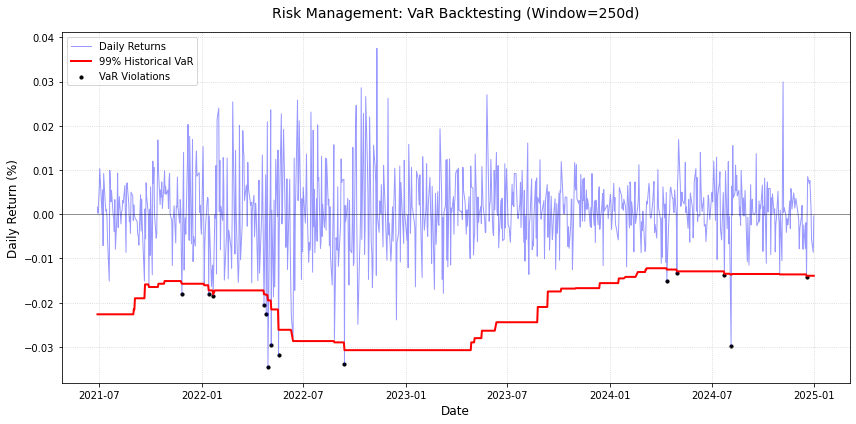

Average VaR: 2.05%
Average CVaR: 2.39%
Days of backtesting: 884days
Count Exception: 14

=== Kupiec POF Test Results ===
Expected Failures : 8.84
Actual Failures   : 14
LR Statistic      : 2.5841
P-value           : 0.1079
Result            : Pass (at 99.0% confidence)


'Pass'

In [58]:
#------------------------------------------------------
#  Evaluate Portfolio.
#------------------------------------------------------

# Sharpe Ratio
mean_return = np.mean(portfolio_returns_m["Portfolio Return_M"]) * 252
volatility = np.std(portfolio_returns_m["Portfolio Return_M"]) * np.sqrt(252)
sharpe_ratio = mean_return / volatility


print(f"Annualized Return: {mean_return:.2%}")
print(f"Annualized Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Historical VaR 계산 (99% 신뢰수준, window=250)
window_VaR= 250
cl = 0.99
portfolio_returns_m.head()

# Calculate historical VaR
portfolio_returns_m['VaR_99_hist'] = portfolio_returns_m['Portfolio Return_M'].rolling(window=window_VaR).quantile(1-cl)

# Calculate historical CVaR
portfolio_returns_m['CVaR_99_hist'] = portfolio_returns_m['Portfolio Return_M'].rolling(window=window_VaR).apply(cvar_calculation, raw=False)

# Backtesting
backtest_df = portfolio_returns_m.dropna().copy()
backtest_df['Exception'] = backtest_df['Portfolio Return_M'] < backtest_df['VaR_99_hist']

# Draw Graph
fig, ax = plt.subplots(figsize=(12, 6))

# Daily Return of Portfolio
ax.plot(backtest_df.index, backtest_df['Portfolio Return_M'],label='Daily Returns', color='blue', alpha=0.4, linewidth=1)
ax.plot(backtest_df.index, backtest_df['VaR_99_hist'],label='99% Historical VaR', color='red', linestyle='-', linewidth=2)

# Highlight the exceptions
exceptions = backtest_df[backtest_df['Exception']]
ax.scatter(exceptions.index, exceptions['Portfolio Return_M'], 
           color='black', marker='o', s=10, label='VaR Violations')

ax.set_title(f'Risk Management: VaR Backtesting (Window={window_VaR}d)', fontsize=14, pad=15)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)  # zero line
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

fig.tight_layout()
plt.show()

# Result
print(f"Average VaR: {abs(np.mean(backtest_df['VaR_99_hist'])):.2%}")
print(f"Average CVaR: {abs(np.mean(backtest_df['CVaR_99_hist'])):.2%}")
print(f"Days of backtesting: {len(backtest_df)}days")
print(f"Count Exception: {backtest_df['Exception'].sum()}")

print(""*20)
print("="*40)
print("="*40)
kupiec_pof_test(backtest_df['Exception'].sum(),
                len(backtest_df), 
                0.99)


In [59]:
# Visualization (Using Monthly rebalancing Portfolio)

def yearly_pie_charts(
    year, 
    weights_df
    ):

    months = weights_df.index[weights_df.index.year == year]
    
    if len(months) == 0:
        print(f"No data available for year {year}.")
        return

    # subplots for 12 months
    fig, axes = plt.subplots(4, 3, figsize=(20, 20), facecolor='white')
    axes = axes.flatten()

    # Iterate for 12 month window
    for i, month in enumerate(months[:12]):  # 최대 12개월까지만
        # locate weights for each months
        monthly_weights = weights_df.loc[month]
        weights_above_0 = monthly_weights[monthly_weights > 1e-4]  # Only above 0.01%
        
        # Draw Pie Charts
        axes[i].pie(
            weights_above_0,
            labels=weights_above_0.index,
            autopct='%1.2f%%'
        )
        axes[i].set_title(f"Monthly Portfolio Weights - {month.strftime('%Y-%m')}")
        axes[i].set_facecolor('white')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle(f"Monthly Rebalanced Portfolio Weights - {year}", fontsize=20, y=1.03)
    plt.show()

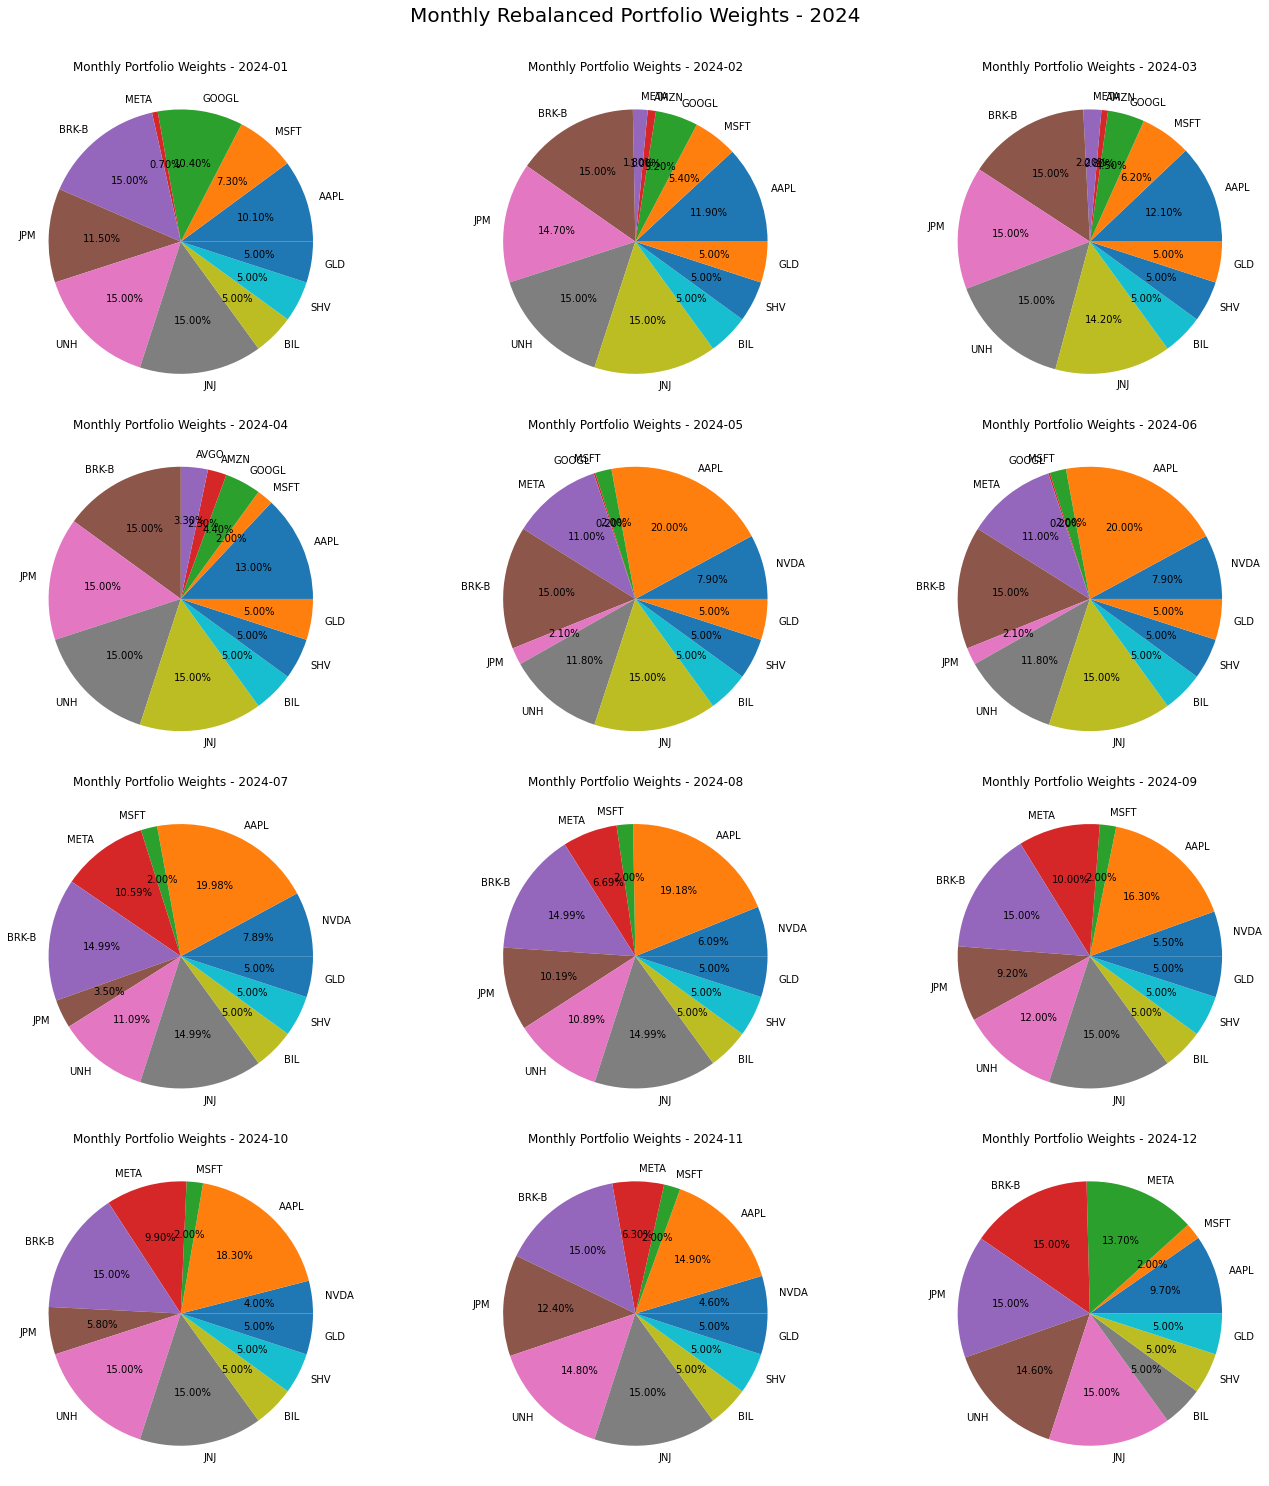

In [60]:
# Portfolio 2024
yearly_pie_charts(2024,weighs_CVaR_m)